# Лабораторная работа №2. Алгоритм Дойча-Йожа

КБ-211 Коренев Денис

## Задание

1. Установить число $n = 4$ и создать соответствующие регистры квантовой схемы.
2. Определить набор значений $x$, для которых функция $b(x) = 1$, а также вид функции $c(x)$.
3. Написать с помощью `def` функции, представляющие собой квантовые вентили $U_c$, $U_b$.
4. Написать скрипт, реализующий по выбору пользователя сценарии «Вова использовал функцию $c$» и «Вова использовал функцию $b$».
5. Запустить скрипт и записать результаты измерений в обоих случаях.
6. Сделать выводы о работе.

In [1]:
from quantumz import initq, H, X, CX, measure, multi_measure
import matplotlib.pyplot as plt

## Параметры задачи

Число кубитов в верхнем регистре Алины: $n = 4$, значит $x \in \{0, 1, \ldots, 15\}$.

Нижний регистр (кубит Вовы) — один кубит-анцилла.

Итого в схеме $n + 1 = 5$ кубитов. В библиотеке `quantumz` квантовое состояние представляется словарём вида `{'|00000>': 1}`, где позиции $0$–$3$ — регистр Алины, позиция $4$ — кубит Вовы.

### Выбор функций

**Постоянная функция:** $c(x) = 1$ для всех $x$. Вентиль $U_c$ — это оператор $X$ (NOT) на анцилле.

**Сбалансированная функция:** $b(x) = x_0 \oplus x_3$ (XOR первого и последнего битов).

$b(x) = 1$ для $x \in \{1, 3, 5, 7, 8, 10, 12, 14\}$ — ровно 8 значений из 16.

Вентиль $U_b$ реализуется двумя последовательными CNOT: `CX([0], 4)` и `CX([3], 4)`.

In [2]:
n = 4  # число кубитов верхнего регистра (Алина)
ancilla = n  # индекс кубита-анциллы (Вова)

print(f"n = {n}")
print(f"Всего кубитов: {n + 1}")
print(f"Верхний регистр (Алина): кубиты 0–{n-1}")
print(f"Нижний регистр (Вова):   кубит {ancilla}")

n = 4
Всего кубитов: 5
Верхний регистр (Алина): кубиты 0–3
Нижний регистр (Вова):   кубит 4


## Определение вентилей $U_c$ и $U_b$

Вентиль $U_f$ действует на систему $|x\rangle|y\rangle \to |x\rangle|y \oplus f(x)\rangle$.

- **$U_c$ при $c(x) = 1$:** анцилла всегда инвертируется — один гейт $X$ на кубите 4.
- **$U_b$ при $b(x) = x_0 \oplus x_3$:** последовательно применяем CNOT с управляющим кубитом 0 и целевым 4, затем CNOT с управляющим 3 и целевым 4.

In [3]:
def Uc(q):
    """
    Вентиль постоянной функции c(x) = 1.
    Инвертирует анциллу независимо от верхнего регистра.
    """
    return X(q, ancilla)


def Ub(q):
    """
    Вентиль сбалансированной функции b(x) = x_0 ⊕ x_3.
    Два последовательных CNOT: управляющие кубиты 0 и 3, целевой — анцилла.
    """
    q = CX(q, [0], ancilla)
    q = CX(q, [3], ancilla)
    return q

print("Вентили Uc, Ub определены.")

Вентили Uc, Ub определены.


## Схема алгоритма Дойча-Йожа

Алгоритм выполняется за один проход:

| Этап | Действие |
|---|---|
| Инициализация | $\|\psi_0\rangle = \|0\rangle^{\otimes n}\|1\rangle$ — верхний регистр в $\|0\rangle$, анцилла в $\|1\rangle$ |
| Адамар | $\|\psi_1\rangle = H^{\otimes(n+1)}\|\psi_0\rangle$ — полная суперпозиция |
| Оракул | $\|\psi_2\rangle = U_f\|\psi_1\rangle$ — применяем $U_c$ или $U_b$ |
| Адамар (верхний) | $\|\psi_3\rangle = (H^{\otimes n} \otimes I)\|\psi_2\rangle$ |
| Измерение | Измеряем верхний регистр: все нули $\Rightarrow c(x)$, иначе $\Rightarrow b(x)$ |

In [4]:
def deutsch_jozsa(oracle, label="f"):
    """
    Выполняет алгоритм Дойча-Йожа с заданным вентилем-оракулом.
    Возвращает словарь вероятностей измерения верхнего регистра.
    """
    # |psi_0> = |0...0>|1>
    q = initq(n + 1)
    q = X(q, ancilla)

    # H на всех кубитах
    for i in range(n + 1):
        q = H(q, i)

    # Применяем оракул Uf
    q = oracle(q)

    # H на верхнем регистре Алины
    for i in range(n):
        q = H(q, i)

    # Измерение верхнего регистра
    probs, states = multi_measure(q, list(range(n)))

    print(f"{'='*50}")
    print(f"  Оракул: {label}")
    print(f"{'='*50}")
    print(f"\n{'Исход':>16} | {'P':>10}")
    print("-" * 32)
    for k in sorted(probs):
        print(f"{k:>16} | {probs[k]:>10.6f}")

    # Проверяем, все ли кубиты в |0>
    all_zeros_key = '|' + '0' * n + '>'
    p_zeros = probs.get(all_zeros_key, 0.0)

    print()
    if p_zeros > 0.99:
        print(f"  P(|{'0'*n}>) = {p_zeros:.6f} ≈ 1")
        print(f"  Вывод: функция ПОСТОЯННАЯ")
    else:
        print(f"  P(|{'0'*n}>) = {p_zeros:.6f} ≈ 0")
        print(f"  Вывод: функция СБАЛАНСИРОВАННАЯ")

    return probs

## Сценарий 1: Вова использует постоянную функцию $c(x) = 1$

Ожидание: при измерении верхнего регистра — все кубиты в состоянии $|0\rangle$, то есть $P(|0000\rangle) = 1$.

In [5]:
probs_c = deutsch_jozsa(Uc, label="c(x) = 1 (постоянная)")

  Оракул: c(x) = 1 (постоянная)

           Исход |          P
--------------------------------
          |0000> |   0.999981

  P(|0000>) = 0.999981 ≈ 1
  Вывод: функция ПОСТОЯННАЯ


## Сценарий 2: Вова использует сбалансированную функцию $b(x) = x_0 \oplus x_3$

Ожидание: при измерении встретится хотя бы одна единица, то есть $P(|0000\rangle) = 0$.

In [6]:
probs_b = deutsch_jozsa(Ub, label="b(x) = x₀ ⊕ x₃ (сбалансированная)")

  Оракул: b(x) = x₀ ⊕ x₃ (сбалансированная)

           Исход |          P
--------------------------------
          |1001> |   0.999981

  P(|0000>) = 0.000000 ≈ 0
  Вывод: функция СБАЛАНСИРОВАННАЯ


## Визуализация результатов

Гистограмма вероятностей измерения верхнего регистра для обоих сценариев.

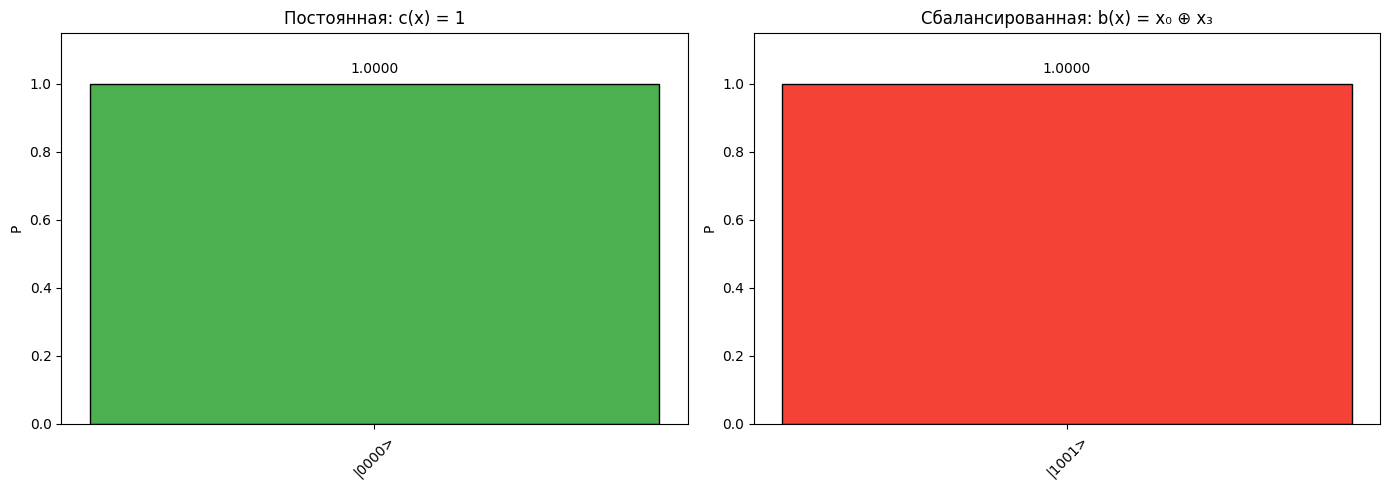

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (probs, title) in zip(axes, [
    (probs_c, "Постоянная: c(x) = 1"),
    (probs_b, "Сбалансированная: b(x) = x₀ ⊕ x₃"),
]):
    labels = sorted(probs.keys())
    values = [probs[k] for k in labels]
    all_zeros = '|' + '0' * n + '>'
    colors = ['#4CAF50' if k == all_zeros else '#F44336' for k in labels]

    bars = ax.bar(labels, values, color=colors, edgecolor='black')
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('P')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, values):
        if val > 0.001:
            ax.text(bar.get_x() + bar.get_width() / 2, val + 0.03,
                    f'{val:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## Проверка таблицы значений $b(x)$

Для верификации вентиля $U_b$ вычислим значения $b(x)$ для всех $x \in \{0, \ldots, 15\}$, подавая на вход базисные состояния $|x\rangle|0\rangle$ и проверяя состояние анциллы после применения $U_b$.

In [8]:
print(f"{'x':>4} | {'двоичн.':>8} | {'b(x)':>4}")
print("-" * 24)

b_one_count = 0
for x in range(2**n):
    bits = format(x, f'0{n}b')
    state_key = '|' + bits + '0>'
    q_test = {state_key: 1}
    q_test = Ub(q_test)
    # Значение b(x) — вероятность получить |1> на анцилле
    b_val = round(measure(q_test, ancilla)[1])
    b_one_count += b_val
    print(f"{x:>4} | {bits:>8} | {b_val:>4}")

print(f"\nВсего b(x)=1: {b_one_count} из {2**n}  →  {'сбалансированная' if b_one_count == 2**n // 2 else 'НЕ сбалансированная'}")

   x |  двоичн. | b(x)
------------------------
   0 |     0000 |    0
   1 |     0001 |    1
   2 |     0010 |    0
   3 |     0011 |    1
   4 |     0100 |    0
   5 |     0101 |    1
   6 |     0110 |    0
   7 |     0111 |    1
   8 |     1000 |    1
   9 |     1001 |    0
  10 |     1010 |    1
  11 |     1011 |    0
  12 |     1100 |    1
  13 |     1101 |    0
  14 |     1110 |    1
  15 |     1111 |    0

Всего b(x)=1: 8 из 16  →  сбалансированная


## Выводы

1. Алгоритм Дойча-Йожа позволяет за **один** сеанс обмена квантовыми состояниями определить тип функции Вовы — постоянная или сбалансированная. В классическом случае для этого потребовалось бы до $2^{n}/2 + 1 = 9$ запросов.

2. Для **постоянной** функции $c(x) = 1$ измерение верхнего регистра даёт $|0000\rangle$ с вероятностью $1$ — все кубиты Алины в нулевом состоянии.

3. Для **сбалансированной** функции $b(x) = x_0 \oplus x_3$ измерение даёт $|1001\rangle$ с вероятностью $1$ — присутствуют единицы, что однозначно указывает на сбалансированную функцию.

4. Эксперимент подтверждает квантовое преимущество: один квантовый запрос заменяет экспоненциальное число классических.